# 1. Load Cleaned Dataset and Inspect Structure

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Purpose:
# - Loading the final cleaned dataset
# - Confirming the dataset shape
# - Displaying the first few rows
# - Printing all column names so we can verify the modelling inputs

import pandas as pd

# Loads the cleaned dataset
df = pd.read_csv("/content/drive/MyDrive/Data Mining /Group/Accidental_Drug_Related_Deaths_CLEANED_V2.csv")

# Displays dataset shape (rows, columns)
print("Dataset shape:", df.shape)

# Displays first 5 rows
print("\nFirst 5 rows of the dataset:")
display(df.head())

# Prints all column names for verification
print("\nColumn names in the dataset:")
for col in df.columns:
    print(col)

Dataset shape: (2396, 52)

First 5 rows of the dataset:


,Date,Age,Sex,Race,Ethnicity,Residence City,Residence County,Residence State,Injury City,Injury County,...,Sex_Encoded,Race_Encoded,Age_Group_Encoded,Mean_Age_That_Year,Age_Deviation_From_Yearly_Mean,Is_Senior,Age_Era,Drug_Count,Polydrug,Died_Alone_At_Home
0,2021-03-26,54.0,Male,Unknown,NaN,TORRINGTON,LITCHFIELD,CT,TORRINGTON,LITCHFIELD,...,1,19,0,45.751312,8.248688,0,Late Era (2020-2023),1,0,0
1,2018-08-18,51.0,Female,Black,NaN,WATERBURY,NEW HAVEN,CT,HARTFORD,HARTFORD,...,0,5,0,42.761062,8.238938,0,Mid Era (2016-2019),5,1,0
2,2016-10-15,33.0,Male,White,NaN,KNOXVILLE,KNOX,TN,BEACON FALLS,Unknown,...,1,20,0,42.082879,-9.082879,0,Mid Era (2016-2019),3,1,0
3,2020-07-29,37.0,Male,White,NaN,NEW HAVEN,NEW HAVEN,CT,NEW HAVEN,NEW HAVEN,...,1,20,0,43.708879,-6.708879,0,Late Era (2020-2023),2,1,0
4,2018-11-13,37.0,Male,White,NaN,WATERBURY,NEW HAVEN,CT,WATERBURY,NEW HAVEN,...,1,20,0,42.761062,-5.761062,0,Mid Era (2016-2019),3,1,1



Column names in the dataset:
Date
Age
Sex
Race
Ethnicity
Residence City
Residence County
Residence State
Injury City
Injury County
Injury State
Injury Place
Death City
Death County
Death State
Location
Heroin
Cocaine
Fentanyl
Fentanyl Analogue
Oxycodone
Oxymorphone
Ethanol
Hydrocodone
Benzodiazepine
Methadone
Meth/Amphetamine
Amphet
Tramad
Hydromorphone
Morphine (Not Heroin)
Xylazine
Gabapentin
Opiate NOS
Any Opioid
Year
Month
DayOfWeek
Season
Age_Group
Age_zscore
Age_MinMax
Sex_Encoded
Race_Encoded
Age_Group_Encoded
Mean_Age_That_Year
Age_Deviation_From_Yearly_Mean
Is_Senior
Age_Era
Drug_Count
Polydrug
Died_Alone_At_Home


# 2. Define Target Variable and Class Distribution Check

In [ ]:
# Purpose:
# - Define the classification target variable
# - Confirm that the target column exists in the dataset
# - Examine the class distribution to detect possible imbalance

# Define the classification target
target = "Age_Group"

# Check whether the target column exists
if target in df.columns:
    print(f"Target column '{target}' found successfully.\n")
else:
    raise ValueError(f"Target column '{target}' not found in the dataset.")

# Create a clean class distribution summary table
class_distribution = pd.DataFrame({
    "Count": df[target].value_counts(),
    "Percentage": (df[target].value_counts(normalize=True) * 100).round(2)
})

# Display class distribution
print("Class distribution summary:")
display(class_distribution)

Target column 'Age_Group' found successfully.

Class distribution summary:


,Count,Percentage
Age_Group,,
Middle-aged (30-60),1733,72.33
Young (0-30),416,17.36
Senior (60+),247,10.31


# 3. Feature Set Select and Create X, Y Variables

In [ ]:
# Purpose:
# - Selecting the input variables used to train the classification model
# - Separating the dataset into features (X) and target label (y)
# - Ensuring the model only uses meaningful predictors

# Lists input features used to predict the age risk group
features = [
    "Sex_Encoded",
    "Race_Encoded",
    "Drug_Count",
    "Polydrug",
    "Died_Alone_At_Home",
    "Year",
    "Month",
    "DayOfWeek",
    "Fentanyl",
    "Cocaine",
    "Heroin",
    "Benzodiazepine"
]

# Creates feature matrix X (independent variables)
X = df[features]

# Creates target variable y
y = df["Age_Group"]

# Displays shapes of X and y
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

# Previews the feature matrix and target variables
display(X.head())
display(y.head())

Feature matrix shape: (2396, 12)
Target vector shape: (2396,)


,Sex_Encoded,Race_Encoded,Drug_Count,Polydrug,Died_Alone_At_Home,Year,Month,DayOfWeek,Fentanyl,Cocaine,Heroin,Benzodiazepine
0,1,19,1,0,0,2021,3,4,0,1,0,0
1,0,5,5,1,0,2018,8,5,1,1,1,1
2,1,20,3,1,0,2016,10,5,1,1,0,0
3,1,20,2,1,0,2020,7,2,1,0,1,0
4,1,20,3,1,1,2018,11,1,1,1,0,0


,Age_Group
0,Middle-aged (30-60)
1,Middle-aged (30-60)
2,Middle-aged (30-60)
3,Middle-aged (30-60)
4,Middle-aged (30-60)


# 4. Split Data into Training and Testing Sets

In [ ]:
# Purpose:
# - Training the model on 80% of the data
# - Testing the model on 20% unseen data
# - Maintaining class balance using stratification

from sklearn.model_selection import train_test_split

# Splits the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% of data for testing
    random_state=42,      # ensures reproducible results
    stratify=y            # preserves class distribution
)

# Checks shapes
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)

print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

Training features shape: (1916, 12)
Testing features shape: (480, 12)
Training labels shape: (1916,)
Testing labels shape: (480,)


# 5. Train Decision Tree Classifier

In [ ]:
# Purpose:
# - Training the first classification model
# - Using the training data only
# - Keeping the model simple and interpretable

from sklearn.tree import DecisionTreeClassifier

# Creates the model
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

# Trains the model
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


# 6. Decision Tree Model Evaluation

In [ ]:
# Purpose:
# - Using the trained model to predict the test set
# - Measuring model performance using standard classification metrics

from sklearn.metrics import accuracy_score, classification_report

# Makes predictions on the test set
y_pred_dt = dt_model.predict(X_test)

# Calculates overall accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", round(dt_accuracy, 4))

# Prints detailed classification metrics
print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7104

Decision Tree Classification Report:
                     precision    recall  f1-score   support

Middle-aged (30-60)       0.72      0.98      0.83       347
       Senior (60+)       0.00      0.00      0.00        50
       Young (0-30)       0.00      0.00      0.00        83

           accuracy                           0.71       480
          macro avg       0.24      0.33      0.28       480
       weighted avg       0.52      0.71      0.60       480



# 7. Decision Tree Confusion Matrix Visualizion

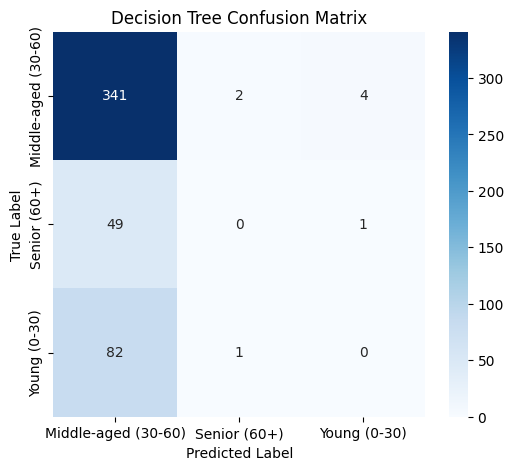

In [ ]:
# Purpose:
# - Visualizing how well the model classified each age group
# - Showing correct and incorrect predictions clearly

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Computes confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Plots confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues",
            xticklabels=dt_model.classes_,
            yticklabels=dt_model.classes_)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# 8. Cross-Validation for Decision Tree

In [ ]:
# Purpose:
# - Evaluating model stability using multiple train/test splits
# - Ensuring results are not dependent on a single split

from sklearn.model_selection import cross_val_score
import numpy as np

# Performs 5-fold cross-validation
cv_scores_dt = cross_val_score(dt_model, X, y, cv=5, scoring="accuracy")

# Prints individual fold scores
print("Cross-validation scores:", cv_scores_dt)

# Prints mean accuracy
print("Mean cross-validation accuracy:", round(np.mean(cv_scores_dt), 4))

# Prints standard deviation (model stability)
print("Standard deviation:", round(np.std(cv_scores_dt), 4))

Cross-validation scores: [0.71666667 0.71398747 0.71607516 0.72025052 0.71607516]
Mean cross-validation accuracy: 0.7166
Standard deviation: 0.002


# 9. Train Random Forest Classifier

In [ ]:
# Purpose:
# - Train the second classification model using Random Forest
# - Use an ensemble approach to improve predictive performance and reduce overfitting

from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

# Train the model on the training data
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


# 10. Random Forest Model Evaluation

In [ ]:
# Purpose:
# - Generate predictions using the trained Random Forest model
# - Evaluate performance using accuracy, precision, recall, and F1-score

from sklearn.metrics import accuracy_score, classification_report

# Generate predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Compute accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

# Display evaluation results
print("Random Forest Hold-Out Accuracy:", round(rf_accuracy, 4))
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Hold-Out Accuracy: 0.7208

Random Forest Classification Report:
                     precision    recall  f1-score   support

Middle-aged (30-60)       0.72      1.00      0.84       347
       Senior (60+)       0.00      0.00      0.00        50
       Young (0-30)       0.00      0.00      0.00        83

           accuracy                           0.72       480
          macro avg       0.24      0.33      0.28       480
       weighted avg       0.52      0.72      0.61       480



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# 11. Random Forest Confusion Matrix Visualization

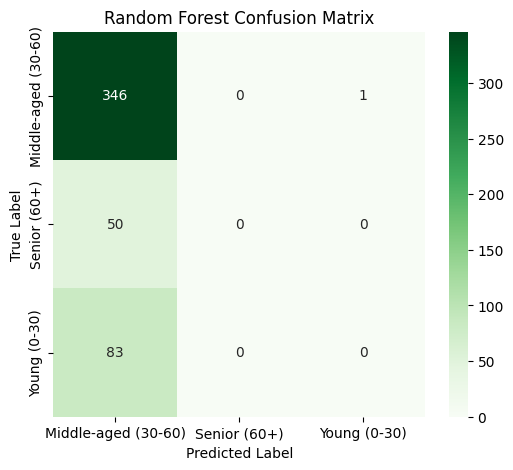

In [ ]:
# Purpose:
# - Visualizing classification performance of Random Forest
# - Showing correct vs incorrect predictions for each class

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Computes confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plots confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=rf_model.classes_,
    yticklabels=rf_model.classes_
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# 12. Cross-Validation for Random Forest

In [ ]:
# Purpose:
# - Evaluating the stability and generalization ability of the Random Forest model
# - Comparing its performance with the Decision Tree using the same validation method

from sklearn.model_selection import cross_val_score
import numpy as np

# Performs 5-fold cross-validation
cv_scores_rf = cross_val_score(rf_model, X, y, cv=5, scoring="accuracy")

# Displays the accuracy of each fold
print("Cross-validation scores:", cv_scores_rf)

# Displays mean accuracy
print("Mean cross-validation accuracy:", round(np.mean(cv_scores_rf), 4))

# Displays standard deviation
print("Standard deviation:", round(np.std(cv_scores_rf), 4))

Cross-validation scores: [0.72291667 0.7223382  0.7223382  0.7223382  0.7223382 ]
Mean cross-validation accuracy: 0.7225
Standard deviation: 0.0002


# 13. Classification Models Performance Comparison

In [ ]:
# Purpose:
# - Summarizing both classification models in one table
# - Comparing test accuracy and cross-validation accuracy

import pandas as pd
import numpy as np

# Creates comparison table
comparison_df = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Test_Accuracy": [dt_accuracy, rf_accuracy],
    "CV_Mean_Accuracy": [np.mean(cv_scores_dt), np.mean(cv_scores_rf)],
    "CV_Std_Dev": [np.std(cv_scores_dt), np.std(cv_scores_rf)]
})

# Rounds values for cleaner display
comparison_df = comparison_df.round(4)

print("Classification Model Comparison:")
display(comparison_df)

Classification Model Comparison:


,Model,Test_Accuracy,CV_Mean_Accuracy,CV_Std_Dev
0,Decision Tree,0.7104,0.7166,0.0020
1,Random Forest,0.7208,0.7225,0.0002


# 14. Random Forest Feature Importance Analysis

Random Forest Feature Importance:


,Feature,Importance
6,Month,0.200204
5,Year,0.175767
7,DayOfWeek,0.151026
2,Drug_Count,0.096624
1,Race_Encoded,0.068387
0,Sex_Encoded,0.052757
10,Heroin,0.049411
4,Died_Alone_At_Home,0.048704
9,Cocaine,0.044513
8,Fentanyl,0.043714


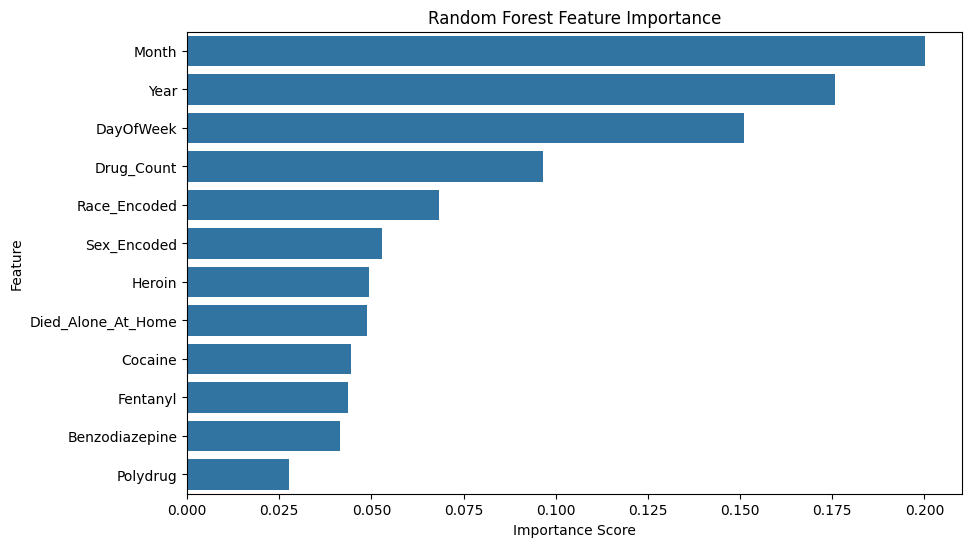

In [ ]:
# Purpose:
# - Identifying which features contribute most to classification
# - Helping interpret the Random Forest model

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Extracts feature importance scores
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sorts features by importance
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

# Displays importance table
print("Random Forest Feature Importance:")
display(feature_importance)

# Plots feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x="Importance", y="Feature")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

# 15. Prepare Clustering Features and Apply Scaling

In [ ]:
# Purpose:
# - Selecting the variables used for clustering
# - Scaling the data so all features contribute fairly
# - K-Means is distance-based, so scaling is necessary

from sklearn.preprocessing import StandardScaler

# Creates Age_Era_Encoded if it does not already exist
if "Age_Era_Encoded" not in df.columns and "Age_Era" in df.columns:
    from sklearn.preprocessing import LabelEncoder
    le_age_era = LabelEncoder()
    df["Age_Era_Encoded"] = le_age_era.fit_transform(df["Age_Era"])

# Selects clustering features
cluster_features = [
    "Age_MinMax",
    "Drug_Count",
    "Polydrug",
    "Died_Alone_At_Home",
    "Fentanyl",
    "Cocaine",
    "Heroin",
    "Benzodiazepine",
    "Age_Era_Encoded"
]

# Creates clustering dataset
X_cluster = df[cluster_features]

# Scales the features
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# Checks shape
print("Clustering feature matrix shape:", X_cluster.shape)
print("Scaled clustering matrix shape:", X_cluster_scaled.shape)

Clustering feature matrix shape: (2396, 9)
Scaled clustering matrix shape: (2396, 9)


# 16. Determining Optimal Number of Clusters Using Elbow Method

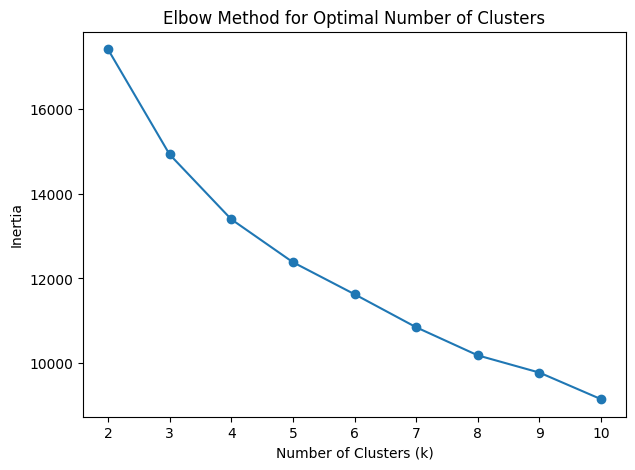

In [ ]:
# Purpose:
# - Running K-Means with different cluster numbers
# - Measuring within-cluster variance (inertia)
# - Identifying the "elbow point" where improvement slows

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Stores inertia values
inertia = []

# Tests cluster numbers from 2 to 10
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)

# Plots elbow curve
plt.figure(figsize=(7,5))
plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

# 17. Train Final K-Means Clustering Model

In [ ]:
# Purpose:
# - Applying K-Means clustering to discover victim profiles
# - Assigning each record to a cluster

from sklearn.cluster import KMeans

# Defines number of clusters (adjusts based on elbow result)
k = 4

# Trains K-Means model
kmeans_model = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

# Fits the model to the scaled data
cluster_labels = kmeans_model.fit_predict(X_cluster_scaled)

# Adds cluster labels to the dataset
df["Cluster"] = cluster_labels

# Checks cluster distribution
print("Cluster distribution:")
print(df["Cluster"].value_counts().sort_index())

Cluster distribution:
Cluster
0    653
1    683
2    542
3    518
Name: count, dtype: int64


# 18. Clustering Performance Evaluation

In [ ]:
# Purpose:
# - Measuring how well the clusters are separated
# - Assessing cluster compactness and quality

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Silhouette Score (higher is better)
sil_score = silhouette_score(X_cluster_scaled, cluster_labels)

# Davies-Bouldin Index (lower is better)
db_score = davies_bouldin_score(X_cluster_scaled, cluster_labels)

# Calinski-Harabasz Score (higher is better)
ch_score = calinski_harabasz_score(X_cluster_scaled, cluster_labels)

print("Silhouette Score:", round(sil_score, 4))
print("Davies-Bouldin Index:", round(db_score, 4))
print("Calinski-Harabasz Score:", round(ch_score, 4))

Silhouette Score: 0.1936
Davies-Bouldin Index: 1.8377
Calinski-Harabasz Score: 485.9658


# 19. Visualize Clusters Using PCA

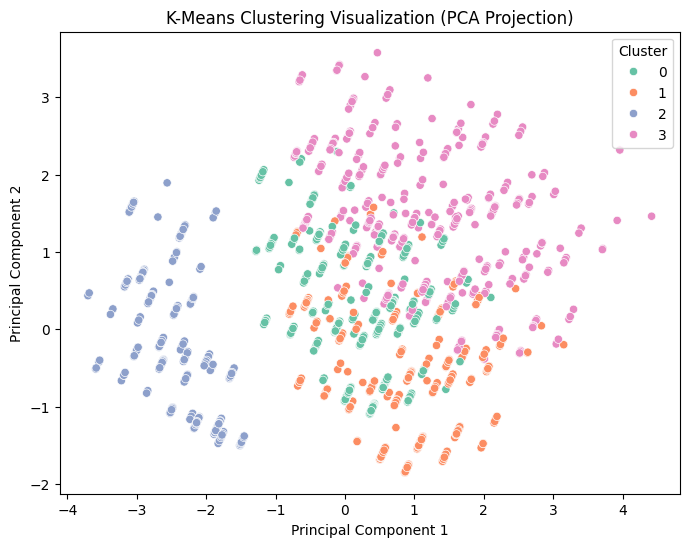

In [ ]:
# Purpose:
# - Reducing high-dimensional data to 2 dimensions
# - Plotting clusters for visual interpretation

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Reduces dimensions to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

# Creates dataframe for plotting
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": cluster_labels
})

# Plots clusters
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2"
)

plt.title("K-Means Clustering Visualization (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

# 20. Cluster Profiles Analysis

In [ ]:
# Purpose:
# - Examining the characteristics of each cluster
# - Identifying patterns in victim profiles

# Calculates mean values of clustering features for each cluster
cluster_profiles = df.groupby("Cluster")[cluster_features].mean()

# Displays cluster profiles
print("Cluster Profiles (Average Feature Values):")
display(cluster_profiles.round(3))

Cluster Profiles (Average Feature Values):


,Age_MinMax,Drug_Count,Polydrug,Died_Alone_At_Home,Fentanyl,Cocaine,Heroin,Benzodiazepine,Age_Era_Encoded
Cluster,,,,,,,,,
0,0.430,2.407,1.0,0.400,0.798,0.000,0.417,0.000,1.251
1,0.413,2.792,1.0,0.247,0.823,1.000,0.259,0.000,1.193
2,0.408,0.961,0.0,0.399,0.369,0.192,0.229,0.022,0.948
3,0.426,3.180,1.0,0.434,0.575,0.259,0.330,1.000,1.230


# 21. Cluster Feature Profiles Visualization

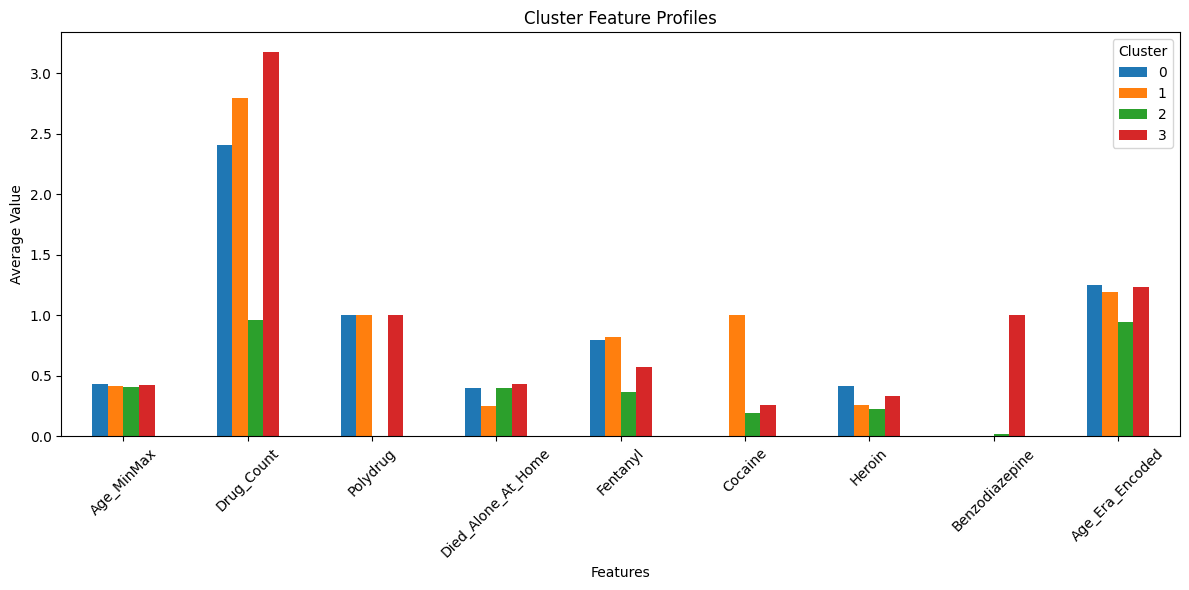

In [ ]:
# Purpose:
# - Comparing average feature values across clusters
# - Making cluster characteristics easier to interpret

import matplotlib.pyplot as plt

# Transposes the cluster profile table for easier plotting
cluster_profiles_T = cluster_profiles.T

# Plots cluster profiles
cluster_profiles_T.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Cluster Feature Profiles")
plt.xlabel("Features")
plt.ylabel("Average Value")
plt.legend(title="Cluster")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 22. Cluster Size Distribution Visualization

Cluster Size Distribution:
Cluster
0    653
1    683
2    542
3    518
Name: count, dtype: int64


/tmp/ipykernel_475/4198300510.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


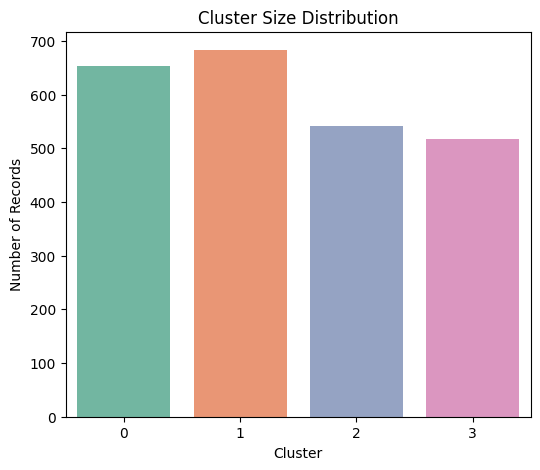

In [ ]:
# Purpose:
# - Showing how many records belong to each cluster
# - Checking whether clusters are balanced

import seaborn as sns
import matplotlib.pyplot as plt

# Counts number of records in each cluster
cluster_counts = df["Cluster"].value_counts().sort_index()

# Displays counts
print("Cluster Size Distribution:")
print(cluster_counts)

# Plots cluster sizes
plt.figure(figsize=(6,5))
sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values,
    palette="Set2"
)

plt.title("Cluster Size Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Records")
plt.show()

# 23. Explore Pairwise Feature Relationships by Cluster

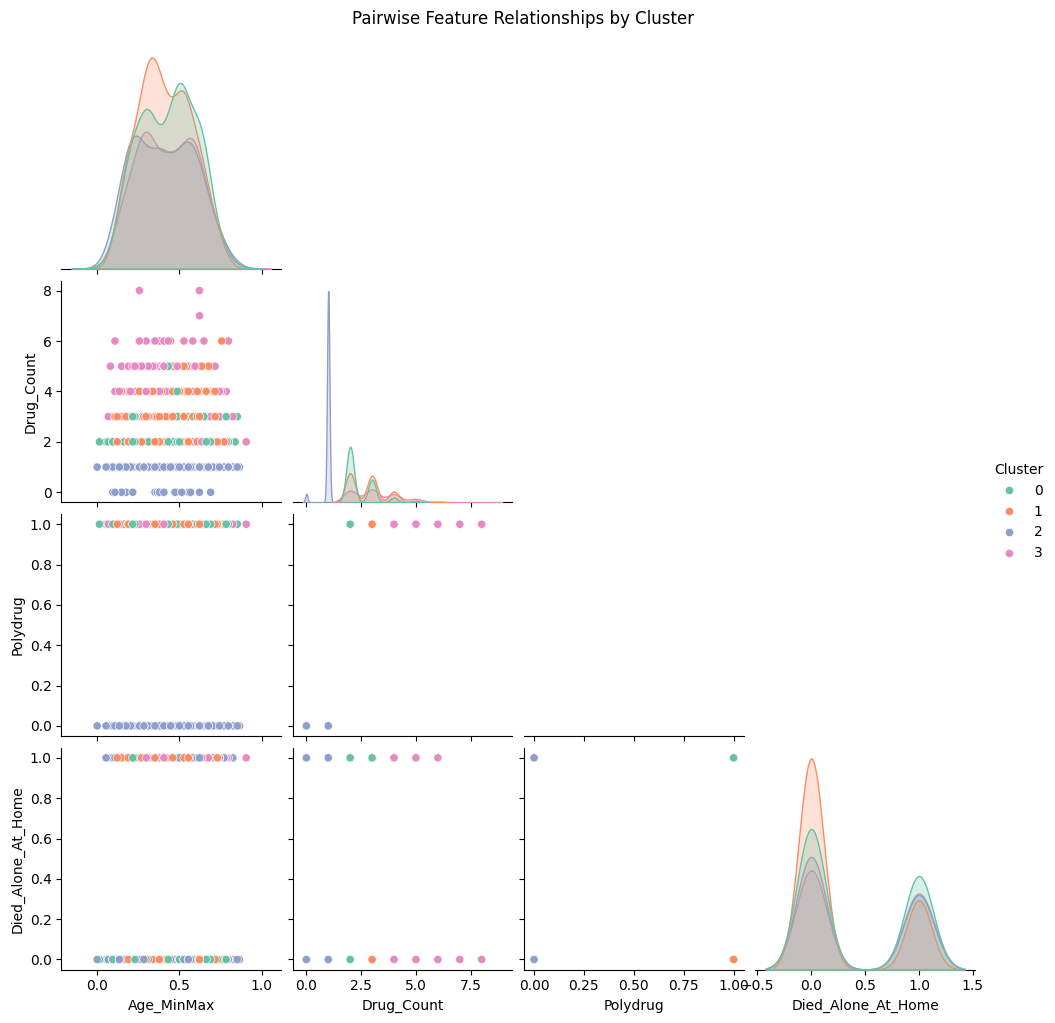

In [ ]:
# Purpose:
# - Showing how the clusters differ across important features
# - Making cluster separation easier to interpret visually

import seaborn as sns
import matplotlib.pyplot as plt

# Selects a few important features for pairwise visualization
pairplot_features = [
    "Age_MinMax",
    "Drug_Count",
    "Polydrug",
    "Died_Alone_At_Home",
    "Cluster"
]

# Creates pairplot
sns.pairplot(
    df[pairplot_features],
    hue="Cluster",
    palette="Set2",
    corner=True
)

plt.suptitle("Pairwise Feature Relationships by Cluster", y=1.02)
plt.show()

# 24. Visualize Cluster Feature Profiles

/tmp/ipykernel_475/2351448923.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_475/2351448923.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_475/2351448923.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_475/2351448923.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


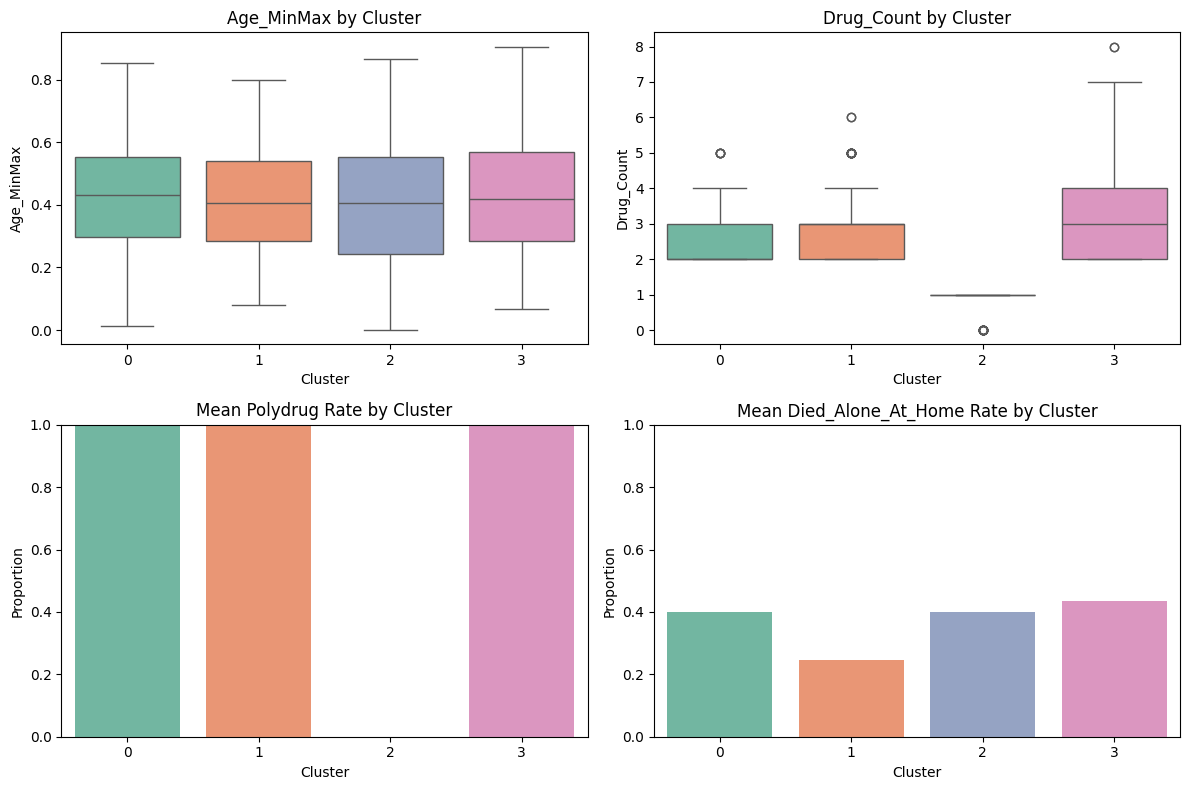

In [ ]:
# Purpose:
# - Using boxplots for continuous features
# - Using bar charts for binary features
# - Producing cleaner and more interpretable cluster visuals

import matplotlib.pyplot as plt
import seaborn as sns

# Creates subplot layout
fig, axes = plt.subplots(2, 2, figsize=(12, 8))


# Boxplot 1: Age_MinMax by Cluster

sns.boxplot(
    data=df,
    x="Cluster",
    y="Age_MinMax",
    ax=axes[0, 0],
    palette="Set2"
)
axes[0, 0].set_title("Age_MinMax by Cluster")
axes[0, 0].set_xlabel("Cluster")
axes[0, 0].set_ylabel("Age_MinMax")


# Boxplot 2: Drug_Count by Cluster

sns.boxplot(
    data=df,
    x="Cluster",
    y="Drug_Count",
    ax=axes[0, 1],
    palette="Set2"
)
axes[0, 1].set_title("Drug_Count by Cluster")
axes[0, 1].set_xlabel("Cluster")
axes[0, 1].set_ylabel("Drug_Count")


# Bar Chart 1: Mean Polydrug Rate by Cluster

polydrug_means = df.groupby("Cluster")["Polydrug"].mean().reset_index()

sns.barplot(
    data=polydrug_means,
    x="Cluster",
    y="Polydrug",
    ax=axes[1, 0],
    palette="Set2"
)
axes[1, 0].set_title("Mean Polydrug Rate by Cluster")
axes[1, 0].set_xlabel("Cluster")
axes[1, 0].set_ylabel("Proportion")
axes[1, 0].set_ylim(0, 1)


# Bar Chart 2: Mean Died_Alone_At_Home Rate by Cluster

alone_means = df.groupby("Cluster")["Died_Alone_At_Home"].mean().reset_index()

sns.barplot(
    data=alone_means,
    x="Cluster",
    y="Died_Alone_At_Home",
    ax=axes[1, 1],
    palette="Set2"
)
axes[1, 1].set_title("Mean Died_Alone_At_Home Rate by Cluster")
axes[1, 1].set_xlabel("Cluster")
axes[1, 1].set_ylabel("Proportion")
axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# 25. Summary Tables

In [ ]:
# Purpose:
# - Summarizing classification model performance
# - Summarizing clustering evaluation results
# - Presenting all key metrics in a clean, report-ready format

from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import numpy as np


# Classification Metrics Summary

classification_summary = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Test Accuracy": [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision (Weighted)": [
        precision_score(y_test, y_pred_dt, average="weighted"),
        precision_score(y_test, y_pred_rf, average="weighted")
    ],
    "Recall (Weighted)": [
        recall_score(y_test, y_pred_dt, average="weighted"),
        recall_score(y_test, y_pred_rf, average="weighted")
    ],
    "F1 Score (Weighted)": [
        f1_score(y_test, y_pred_dt, average="weighted"),
        f1_score(y_test, y_pred_rf, average="weighted")
    ],
    "CV Mean Accuracy": [
        np.mean(cv_scores_dt),
        np.mean(cv_scores_rf)
    ],
    "CV Std Dev": [
        np.std(cv_scores_dt),
        np.std(cv_scores_rf)
    ]
})

# Rounds for neat display
classification_summary = classification_summary.round(4)


# Clustering Metrics Summary

clustering_summary = pd.DataFrame({
    "Clustering Model": ["K-Means"],
    "Number of Clusters (k)": [k],
    "Silhouette Score": [sil_score],
    "Davies-Bouldin Index": [db_score],
    "Calinski-Harabasz Score": [ch_score]
})

# Rounds for neat display
clustering_summary = clustering_summary.round(4)


# Displays Results

print("Classification Performance Summary")
display(classification_summary)

print("Clustering Evaluation Summary")
display(clustering_summary)

Classification Performance Summary


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Test Accuracy,Precision (Weighted),Recall (Weighted),F1 Score (Weighted),CV Mean Accuracy,CV Std Dev
0,Decision Tree,0.7104,0.5223,0.7104,0.6020,0.7166,0.0020
1,Random Forest,0.7208,0.5222,0.7208,0.6056,0.7225,0.0002


Clustering Evaluation Summary


,Clustering Model,Number of Clusters (k),Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,K-Means,4,0.1936,1.8377,485.9658


# 26. Export Key Results

In [ ]:
# Purpose:
# - Saving important outputs
# - Keeping results organized in one folder

import os

# Creates results folder
results_dir = "results"
os.makedirs(results_dir, exist_ok=True)

# Exports summary tables
classification_summary.to_csv(f"{results_dir}/classification_summary.csv", index=False)
clustering_summary.to_csv(f"{results_dir}/clustering_summary.csv", index=False)

# Exports cluster profiles and cluster counts
cluster_profiles.to_csv(f"{results_dir}/cluster_profiles.csv")
cluster_counts.to_csv(f"{results_dir}/cluster_size_distribution.csv", header=["Count"])

# Exports feature importance
feature_importance.to_csv(f"{results_dir}/random_forest_feature_importance.csv", index=False)

# Exports PCA coordinates with cluster labels
pca_df.to_csv(f"{results_dir}/pca_cluster_projection.csv", index=False)

print("All key results have been exported successfully to the 'results' folder.")

All key results have been exported successfully to the 'results' folder.


# 27. Final Modelling Summary

In [ ]:
# Purpose:
# - Identifying the best classification model
# - Presenting a concise final summary of classification and clustering results
# - Ending the notebook with a clean, publication-style summary

# Selects best classification model based on weighted F1-score
best_model_row = classification_summary.loc[
    classification_summary["F1 Score (Weighted)"].idxmax()
]

best_model_name = best_model_row["Model"]
best_model_f1 = best_model_row["F1 Score (Weighted)"]
best_model_accuracy = best_model_row["Test Accuracy"]
best_model_cv = best_model_row["CV Mean Accuracy"]

print("=" * 65)
print("FINAL MODELLING SUMMARY")
print("=" * 65)

print("\n[1] BEST CLASSIFICATION MODEL")
print(f"Selected Model          : {best_model_name}")
print(f"Hold-Out Accuracy       : {best_model_accuracy:.4f}")
print(f"Weighted F1-Score       : {best_model_f1:.4f}")
print(f"Cross-Validation Mean   : {best_model_cv:.4f}")

print("\n[2] CLASSIFICATION MODELS OVERVIEW")
display(classification_summary)

print("\n[3] CLUSTERING MODEL OVERVIEW")
display(clustering_summary)

print("\n[4] FINAL CLUSTERING METRICS")
print(f"Number of Clusters      : {k}")
print(f"Silhouette Score        : {sil_score:.4f}")
print(f"Davies-Bouldin Index    : {db_score:.4f}")
print(f"Calinski-Harabasz Score : {ch_score:.4f}")


FINAL MODELLING SUMMARY

[1] BEST CLASSIFICATION MODEL
Selected Model          : Random Forest
Hold-Out Accuracy       : 0.7208
Weighted F1-Score       : 0.6056
Cross-Validation Mean   : 0.7225

[2] CLASSIFICATION MODELS OVERVIEW


,Model,Test Accuracy,Precision (Weighted),Recall (Weighted),F1 Score (Weighted),CV Mean Accuracy,CV Std Dev
0,Decision Tree,0.7104,0.5223,0.7104,0.6020,0.7166,0.0020
1,Random Forest,0.7208,0.5222,0.7208,0.6056,0.7225,0.0002



[3] CLUSTERING MODEL OVERVIEW


,Clustering Model,Number of Clusters (k),Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,K-Means,4,0.1936,1.8377,485.9658



[4] FINAL CLUSTERING METRICS
Number of Clusters      : 4
Silhouette Score        : 0.1936
Davies-Bouldin Index    : 1.8377
Calinski-Harabasz Score : 485.9658


# 28. Export Key Plots

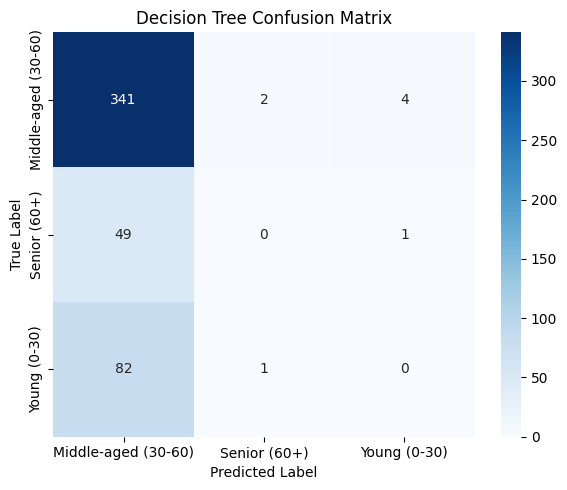

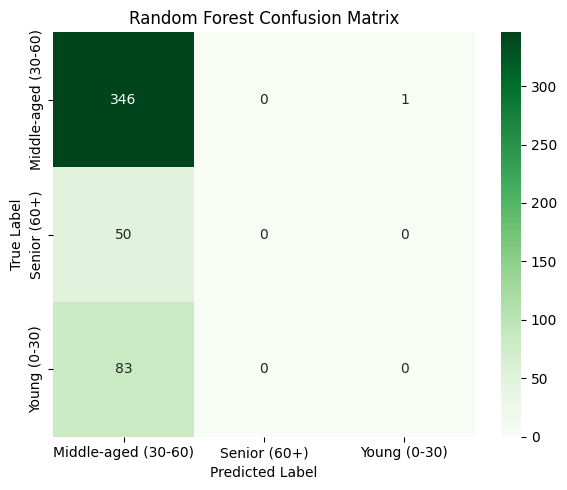

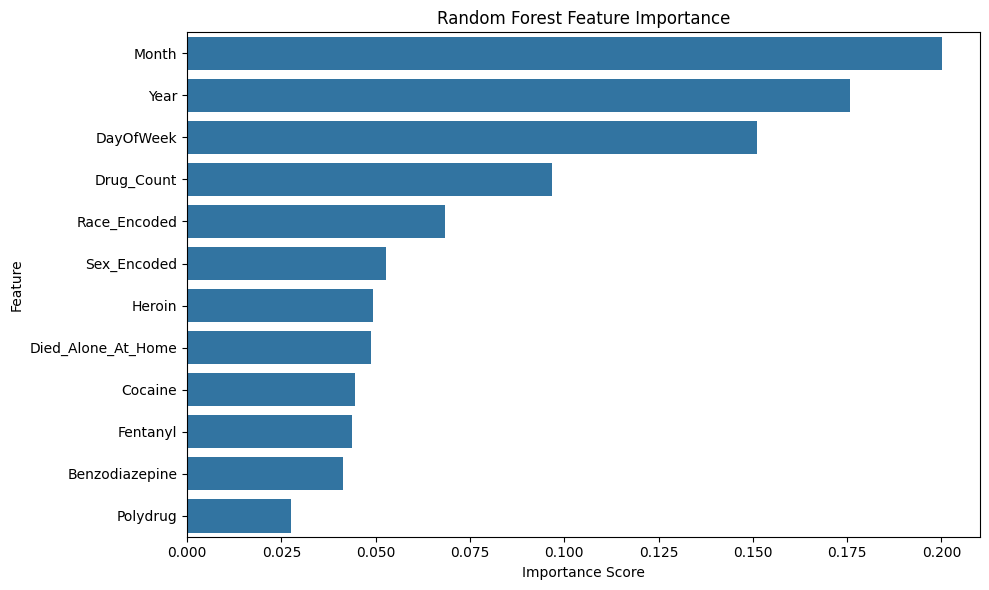

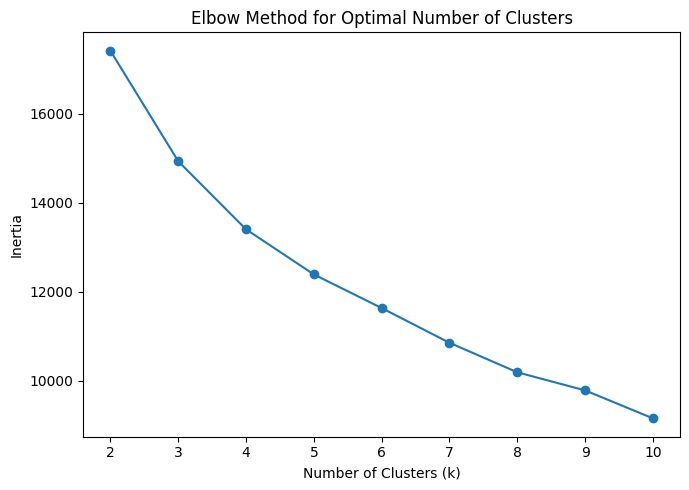

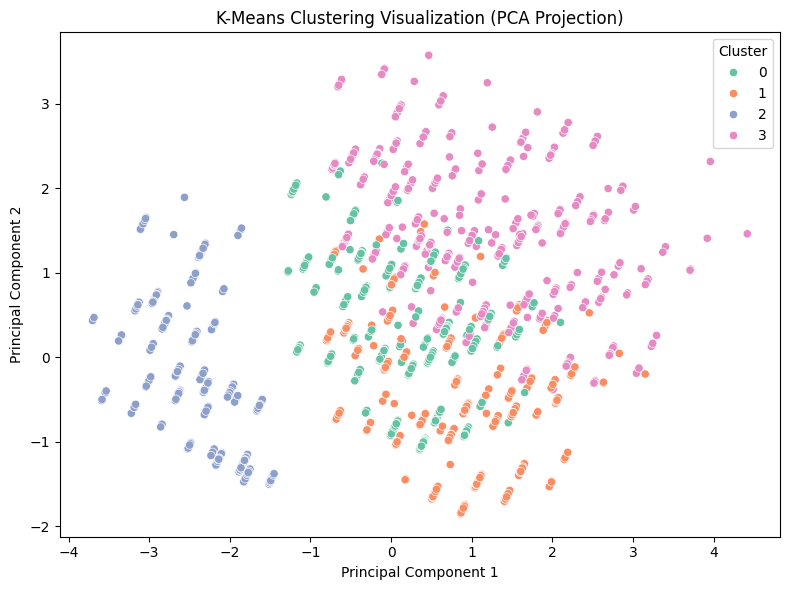

/tmp/ipykernel_475/1580455863.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


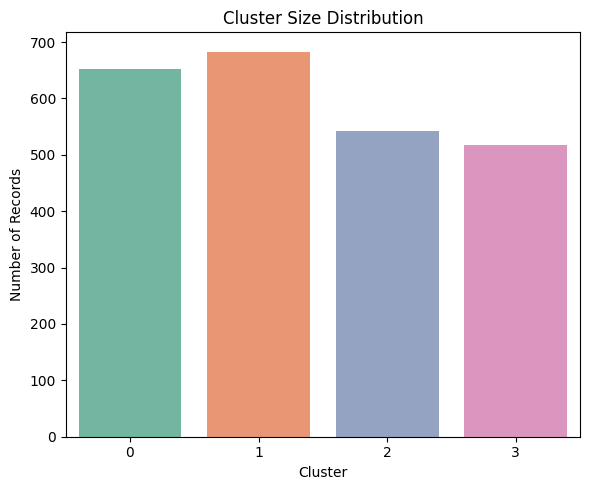

All key plots have been exported successfully to the 'plots' folder.


In [ ]:
# Purpose:
# - Saving important figures as high-quality image files
# - Keeping all visuals organized in one folder

import os
import matplotlib.pyplot as plt
import seaborn as sns

# Create plots folder
plots_dir = "plots"
os.makedirs(plots_dir, exist_ok=True)


# Plot 1: Decision Tree Confusion Matrix

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=dt_model.classes_,
    yticklabels=dt_model.classes_
)
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig(f"{plots_dir}/decision_tree_confusion_matrix.png", dpi=300)
plt.show()


# Plot 2: Random Forest Confusion Matrix

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=rf_model.classes_,
    yticklabels=rf_model.classes_
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig(f"{plots_dir}/random_forest_confusion_matrix.png", dpi=300)
plt.show()


# Plot 3: Random Forest Feature Importance

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x="Importance", y="Feature")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(f"{plots_dir}/random_forest_feature_importance.png", dpi=300)
plt.show()


# Plot 4: Elbow Method

plt.figure(figsize=(7, 5))
plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.savefig(f"{plots_dir}/elbow_method.png", dpi=300)
plt.show()


# Plot 5: PCA Cluster Visualization

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2"
)
plt.title("K-Means Clustering Visualization (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.savefig(f"{plots_dir}/kmeans_pca_clusters.png", dpi=300)
plt.show()


# Plot 6: Cluster Size Distribution

plt.figure(figsize=(6, 5))
sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values,
    palette="Set2"
)
plt.title("Cluster Size Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.savefig(f"{plots_dir}/cluster_size_distribution.png", dpi=300)
plt.show()

print("All key plots have been exported successfully to the 'plots' folder.")

# 29. Export Final Model Outputs

In [ ]:
# Purpose:
# - Savjng the full dataset with cluster assignments
# - Saving classification predictions on the test set
# - Keeping modelling outputs organized for later inspection


# Saves full dataset with cluster labels
df.to_csv(f"{results_dir}/dataset_with_clusters.csv", index=False)


# Saves classification predictions on the test set
classification_predictions = X_test.copy()
classification_predictions["Actual_Age_Group"] = y_test.values
classification_predictions["DecisionTree_Prediction"] = y_pred_dt
classification_predictions["RandomForest_Prediction"] = y_pred_rf

classification_predictions.to_csv(
    f"{results_dir}/classification_test_predictions.csv",
    index=False
)

print("Final modelling outputs exported successfully:")
print(f"- {results_dir}/dataset_with_clusters.csv")
print(f"- {results_dir}/classification_test_predictions.csv")

Final modelling outputs exported successfully:
- results/dataset_with_clusters.csv
- results/classification_test_predictions.csv


# Anomally Detection

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Use already engineered feature (correct approach)
# Age_Deviation_From_Yearly_Mean = core signal

ad_features = ["Age_Deviation_From_Yearly_Mean", "Drug_Count", "Died_Alone_At_Home"]
X_ad = df[ad_features].fillna(0)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_ad)

# Isolation Forest
iso = IsolationForest(contamination=0.03, random_state=42)
df["anomaly_iso"] = (iso.fit_predict(X_scaled) == -1).astype(int)

print("Isolation Forest anomalies:", df["anomaly_iso"].sum())

Isolation Forest anomalies: 71


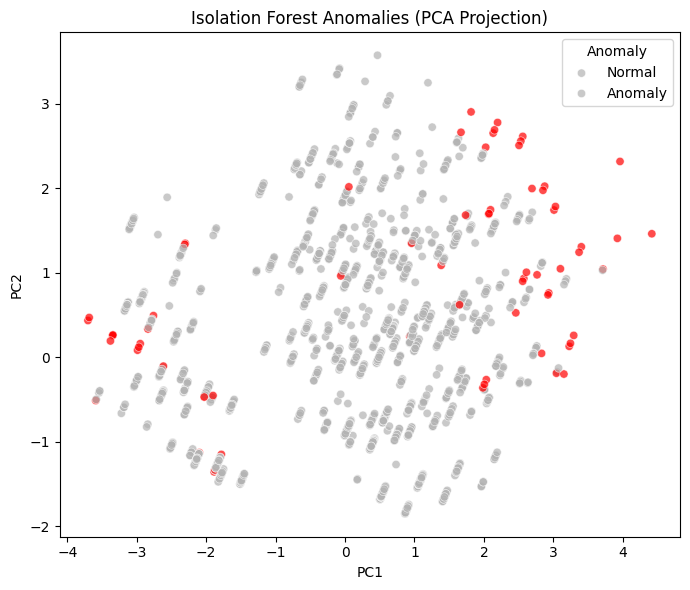

In [ ]:
plt.figure(figsize=(7,6))

sns.scatterplot(
    data=pca_df,
    x="PC1", y="PC2",
    hue=df["anomaly_iso"],
    palette={0: "0.7", 1: "red"},
    alpha=0.7
)

plt.title("Isolation Forest Anomalies (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Anomaly", labels=["Normal", "Anomaly"])

plt.tight_layout()
plt.savefig(f"{plots_dir}/isolation_forest_pca.png", dpi=300)
plt.show()

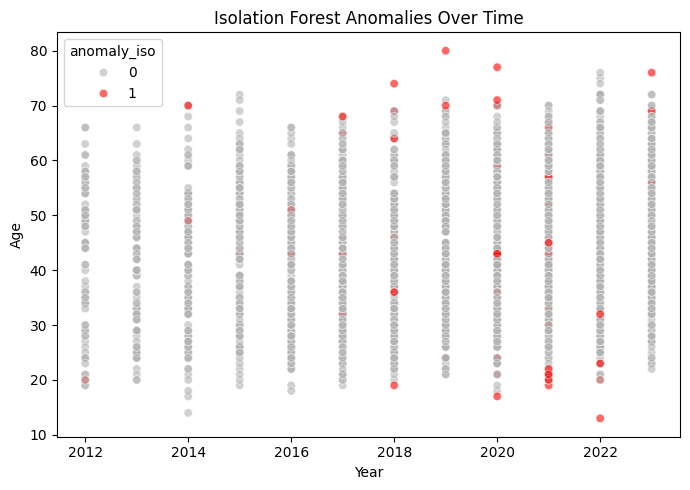

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="Year",
    y="Age",
    hue="anomaly_iso",
    palette={0: "0.7", 1: "red"},
    alpha=0.6
)

plt.title("Isolation Forest Anomalies Over Time")
plt.ylabel("Age")
plt.xlabel("Year")

plt.tight_layout()
plt.show()

In [ ]:
# Isolation Forest anomalies
iso_samples = df[df["anomaly_iso"] == 1][[
    "Year", "Age", "Age_Deviation_From_Yearly_Mean",
    "Drug_Count", "Polydrug", "Died_Alone_At_Home"
]].head(10)

print("Isolation Forest anomaly samples:")
display(iso_samples)

Isolation Forest anomaly samples:


,Year,Age,Age_Deviation_From_Yearly_Mean,Drug_Count,Polydrug,Died_Alone_At_Home
60,2023,59.0,11.008289,8,1,0
67,2018,74.0,31.238938,1,0,1
167,2020,60.0,16.291121,5,1,1
190,2020,24.0,-19.708879,5,1,1
215,2017,33.0,-8.730250,5,1,1
216,2015,43.0,0.696845,0,0,1
308,2017,65.0,23.269750,5,1,1
317,2019,40.0,-3.276667,0,0,1
321,2020,21.0,-22.708879,6,1,0
329,2021,20.0,-25.751312,1,0,1


# Z-SCORE

In [ ]:
# Already normalized relative to yearly mean → just standardize it
df["zscore_year"] = (
    df["Age_Deviation_From_Yearly_Mean"] /
    df.groupby("Year")["Age_Deviation_From_Yearly_Mean"].transform("std")
)

threshold = df["zscore_year"].abs().quantile(0.99)
df["anomaly_stat"] = (df["zscore_year"].abs() > threshold).astype(int)

print("Z-score anomalies:", df["anomaly_stat"].sum())

Z-score anomalies: 23


In [ ]:
# Z-score anomalies
stat_samples = df[df["anomaly_stat"] == 1][[
    "Year", "Age", "Age_Deviation_From_Yearly_Mean",
    "Drug_Count", "Polydrug", "Died_Alone_At_Home"
]].head(10)

print("Z-score anomaly samples:")
display(stat_samples)

Z-score anomaly samples:


,Year,Age,Age_Deviation_From_Yearly_Mean,Drug_Count,Polydrug,Died_Alone_At_Home
67,2018,74.0,31.238938,1,0,1
119,2022,75.0,28.367769,2,1,0
158,2022,76.0,29.367769,3,1,0
304,2015,72.0,29.696845,2,1,1
319,2014,70.0,28.417563,3,1,1
510,2014,14.0,-27.582437,2,1,0
540,2022,13.0,-33.632231,1,0,0
680,2021,19.0,-26.751312,1,0,1
989,2018,69.0,26.238938,3,1,1
1016,2019,71.0,27.723333,3,1,0


#Z-Score Distribution Over Time

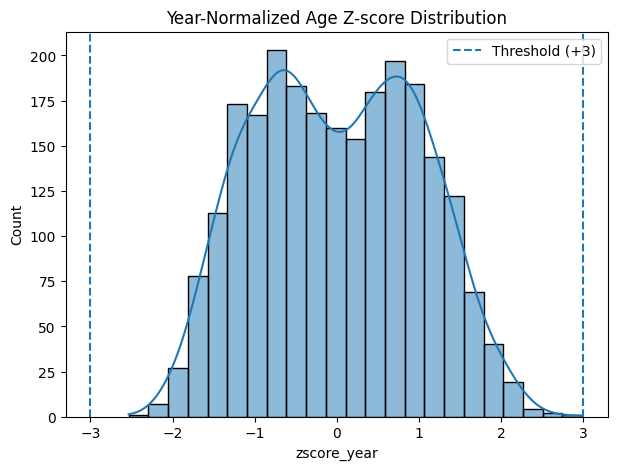

In [ ]:
plt.figure(figsize=(7,5))
sns.histplot(df["zscore_year"], kde=True)
plt.axvline(3, linestyle='--', label='Threshold (+3)')
plt.axvline(-3, linestyle='--')
plt.title("Year-Normalized Age Z-score Distribution")
plt.legend()
plt.show()

#Comparison

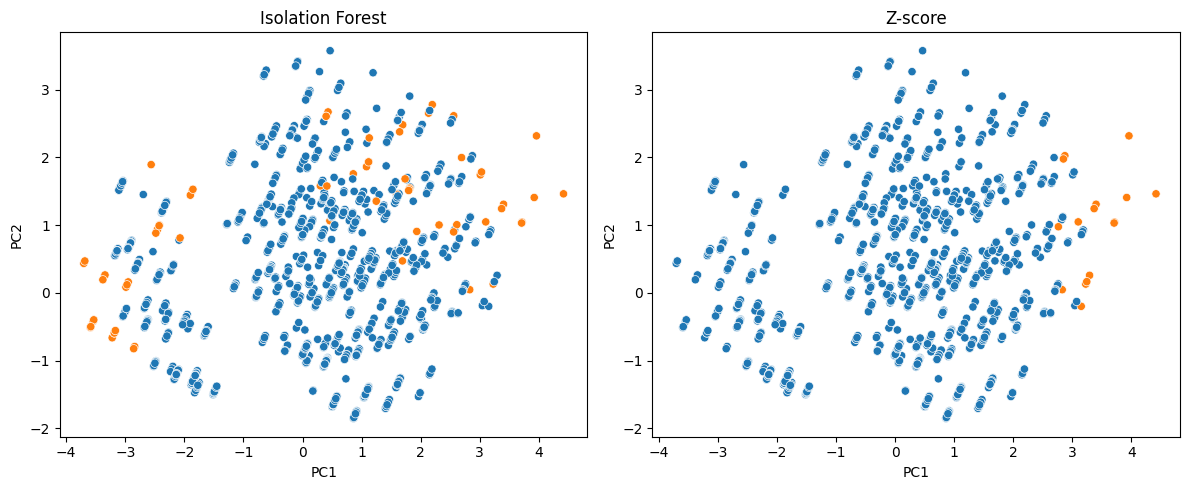

In [ ]:
pca_df = pd.read_csv(f"{results_dir}/pca_cluster_projection.csv")

pca_df["anomaly_iso"] = df["anomaly_iso"]
pca_df["anomaly_stat"] = df["anomaly_stat"]

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.scatterplot(data=pca_df, x="PC1", y="PC2",
                hue="anomaly_iso", ax=axes[0], legend=False)
axes[0].set_title("Isolation Forest")

sns.scatterplot(data=pca_df, x="PC1", y="PC2",
                hue="anomaly_stat", ax=axes[1], legend=False)
axes[1].set_title("Z-score")

plt.tight_layout()
plt.show()

# Anomalies Detected Comparison

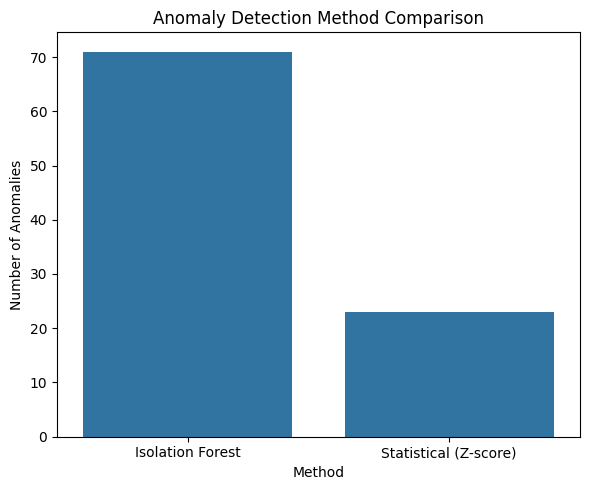

In [ ]:
comparison = pd.DataFrame({
    "Method": ["Isolation Forest", "Statistical (Z-score)"],
    "Anomalies Detected": [
        df["anomaly_iso"].sum(),
        df["anomaly_stat"].sum()
    ]
})

comparison.to_csv(f"{results_dir}/anomaly_comparison.csv", index=False)

plt.figure(figsize=(6,5))

sns.barplot(
    data=comparison,
    x="Method",
    y="Anomalies Detected"
)

plt.title("Anomaly Detection Method Comparison")
plt.xlabel("Method")
plt.ylabel("Number of Anomalies")

plt.tight_layout()
plt.savefig(f"{plots_dir}/anomaly_method_comparison.png", dpi=300)
plt.show()

# Time Series Regression

In [ ]:
yearly = df.groupby("Year")["Age"].mean().reset_index()
yearly.columns = ["Year", "Mean_Age"]

# Train Model

In [ ]:
from sklearn.linear_model import LinearRegression

X_ts = yearly[["Year"]]
y_ts = yearly["Mean_Age"]

model = LinearRegression()
model.fit(X_ts, y_ts)

LinearRegression()

# Forcast 2024–2026

In [ ]:
future_years = pd.DataFrame({"Year": [2024, 2025, 2026]})
future_preds = model.predict(future_years)

future_years["Predicted_Mean_Age"] = future_preds
print(future_years)

   Year  Predicted_Mean_Age
0  2024           46.614094
1  2025           47.089114
2  2026           47.564134


# Predict when age median exceeds 50

In [ ]:
year_check = 2024
while True:
    pred = model.predict([[year_check]])[0]
    if pred > 50:
        print("Mean age exceeds 50 in:", year_check)
        break
    year_check += 1

Mean age exceeds 50 in: 2032


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/

# Mean Age Forecast

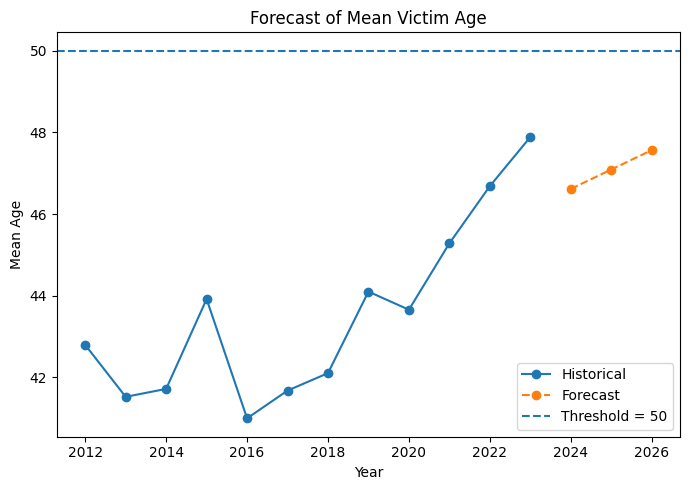

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(yearly["Year"], yearly["Mean_Age"], marker='o', label="Historical")
plt.plot(future_years["Year"], future_years["Predicted_Mean_Age"],
         marker='o', linestyle='--', label="Forecast")

plt.axhline(50, linestyle='--', label="Threshold = 50")

plt.xlabel("Year")
plt.ylabel("Mean Age")
plt.title("Forecast of Mean Victim Age")
plt.legend()
plt.tight_layout()
plt.show()

# Save Results

In [ ]:
future_years.to_csv(f"{results_dir}/age_forecast.csv", index=False)